## 🔧 Environment Setup & Checkpoint Loading

_Added to fix the cross-notebook data-flow issue: this cell imports the common libraries this notebook needs, and defines helper functions to save/load intermediate results so this notebook works correctly whether it's run right after the previous one or on its own, days later, after the raw data has changed._

In [1]:
# 🔧 SETUP: local paths, common imports & checkpoint utilities
# This cell fixes the "notebook 2 can't see notebook 1's data" problem: instead
# of relying on variables still sitting in memory from another notebook (which
# never works once notebooks are split into separate .ipynb files, or run in
# separate VS Code kernels), every notebook loads what it needs from a shared
# "checkpoints" folder on disk, and saves what later notebooks need back to
# that same folder.

import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# 📁 Data lives in a `data` folder that's a *sibling* of the folder these
# notebooks are run from (e.g. `project/notebooks/*.ipynb` + `project/data/`).
# This resolves the same way no matter whose machine it runs on - no
# usernames or absolute paths baked in. Adjust the '..' below if your data
# folder sits somewhere else relative to your notebooks.
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'data'))
DATA_DIR = BASE_DIR
CKPT_DIR = os.path.join(BASE_DIR, 'checkpoints')
os.makedirs(CKPT_DIR, exist_ok=True)


def save_ckpt(obj, name):
    """Save a variable to the shared checkpoint folder so later notebooks can load it."""
    path = os.path.join(CKPT_DIR, f'{name}.pkl')
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    print(f"✅ Saved checkpoint '{name}' -> {path}")


def load_ckpt(name):
    """Load a variable that was saved by an earlier notebook in this pipeline."""
    path = os.path.join(CKPT_DIR, f'{name}.pkl')
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"❌ Checkpoint '{name}' not found at {path}.\n"
            f"   Make sure you have run the earlier notebook(s) in the pipeline first "
            f"(they save this checkpoint at their final cell), and that BASE_DIR "
            f"above points at the right folder."
        )
    with open(path, 'rb') as f:
        obj = pickle.load(f)
    print(f"✅ Loaded checkpoint '{name}' <- {path}")
    return obj


C:\Users\arushi khare\AppData\Local\Temp\ipykernel_25836\1428146299.py:11: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## 📥 Load Checkpoints From Earlier Notebooks

In [2]:
# 📥 Load the variables this notebook needs from earlier notebooks in the pipeline
stores = load_ckpt('stores')
cluster_df = load_ckpt('part4_cluster_df')
store_df = load_ckpt('part4_store_df')
df_pca = load_ckpt('part4_df_pca')
dept_df = load_ckpt('part4_dept_df')
df_pca1 = load_ckpt('part4_df_pca1')


✅ Loaded checkpoint 'stores' <- c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\data\checkpoints\stores.pkl
✅ Loaded checkpoint 'part4_cluster_df' <- c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\data\checkpoints\part4_cluster_df.pkl
✅ Loaded checkpoint 'part4_store_df' <- c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\data\checkpoints\part4_store_df.pkl
✅ Loaded checkpoint 'part4_df_pca' <- c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\data\checkpoints\part4_df_pca.pkl
✅ Loaded checkpoint 'part4_dept_df' <- c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\data\checkpoints\part4_dept_df.pkl
✅ Loaded checkpoint 'part4_df_pca1' <- c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\data\checkpoints\part4_df_pca1.pkl


## 📈 Cluster Evaluation Insight (Department-wise Clustering)

Based on the silhouette scores for different values of `n_clusters`, we observe the following:

| Number of Clusters | Average Silhouette Score |
|--------------------|--------------------------|
| 2                  | **0.5093**               |
| 3                  | 0.3726                   |
| 4                  | 0.3913                   |
| 5                  | 0.4059                   |
| 6                  | 0.3531                   |
| 7                  | 0.3421                   |
| 8                  | 0.3443                   |
| 9                  | 0.3273                   |

### 🔍 Insight:

- The **highest silhouette score** is observed when `n_clusters = 2`, indicating the most **well-separated and cohesive clusters**.
- As the number of clusters increases beyond 2, the silhouette score **gradually decreases**, suggesting **less distinct groupings**.
- Therefore, for department-wise clustering, choosing **2 clusters** offers the **best segmentation quality** in terms of **compactness and separation**.


### 🏬 Store Segmentation Analysis

Now that dimensionality reduction using **PCA** has been completed and the **optimal number of clusters** has been determined using **Elbow Method** and **Silhouette Score**, we proceed to **segment the stores** based on their sales behavior, markdown patterns, and other normalized features.

---

**✅ Objective:**
- Group similar stores into clusters to identify behavioral patterns.
- Understand how store characteristics like sales, markdowns, and regional factors influence performance.

**🛠️ Method:**
- Apply **KMeans clustering** to PCA-transformed data.
- Assign a cluster label to each store.

This segmentation will help in:
- Tailoring marketing and inventory strategies per cluster.
- Identifying high-performing vs. low-performing store segments.


### 📊 Cluster Visualization (Store Segmentation)

Now that we’ve identified the optimal number of clusters (K = 4), we use **KMeans** to segment the stores and visualize them using the first two principal components (from PCA).

Each color in the scatter plot below represents a unique store cluster, allowing us to observe how distinct the clusters are in the reduced feature space.

This visualization helps in:
- Understanding the **distribution of stores** across clusters
- Verifying the **separation and compactness** of clusters
- Identifying possible outliers or overlaps between clusters


C:\Users\arushi khare\AppData\Local\Temp\ipykernel_25836\1574079572.py:27: UserWarning: Glyph 128717 (\N{SHOPPING BAGS}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128717 (\N{SHOPPING BAGS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


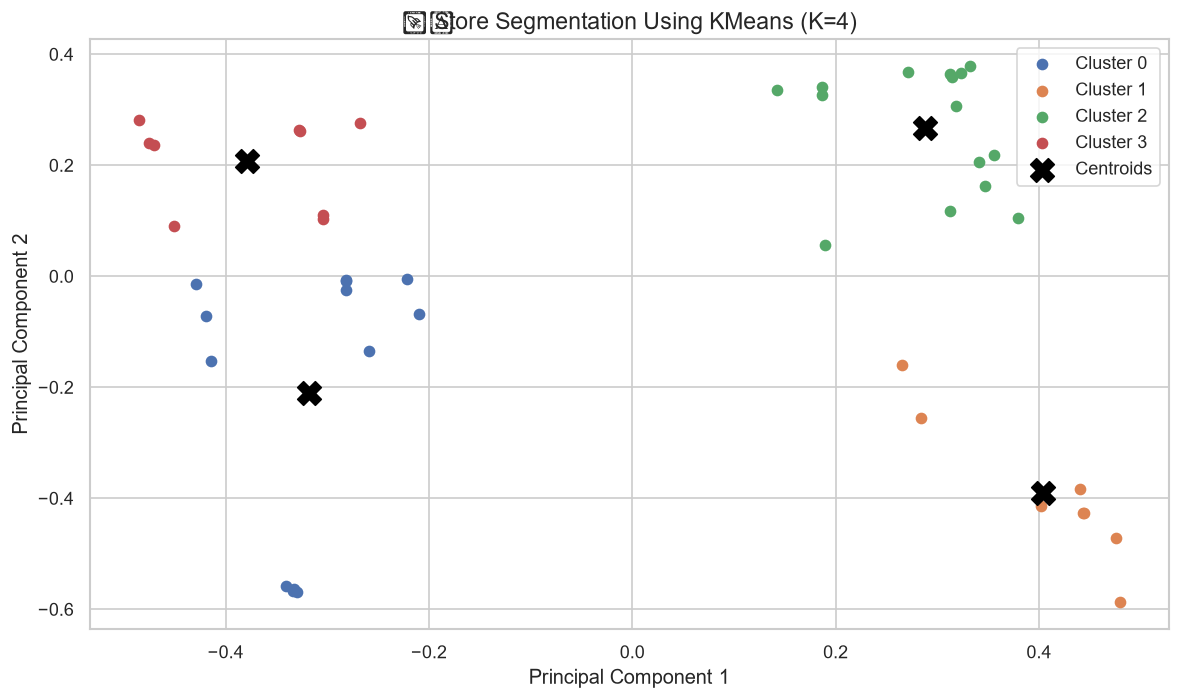

In [3]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np

# Fit KMeans with the chosen number of clusters (e.g., 4)
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
label = kmeans.fit_predict(df_pca)

# Get unique cluster labels
unique_labels = np.unique(label)

# Plot the clusters
plt.figure(figsize=(10, 6), dpi=120)
for i in unique_labels:
    plt.scatter(df_pca[label == i, 0], df_pca[label == i, 1], label=f'Cluster {i}')

# Add cluster centers to the plot
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, marker='X', label='Centroids')

# Final plot formatting
plt.title("🛍️ Store Segmentation Using KMeans (K=4)", fontsize=14)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [4]:
# 📊 Creating a DataFrame for PCA-transformed data with cluster labels

# Convert the PCA results into a DataFrame
kmeans_pca_df = pd.DataFrame(df_pca, columns=['PC1', 'PC2', 'PC3'], index=stores.index)

# Add the cluster label column
kmeans_pca_df["label"] = label

# Preview 5 random rows (sorted by index for consistency)
kmeans_pca_df.sample(5).sort_index(ascending=True)

,PC1,PC2,PC3,label
15,0.284288,-0.255767,-0.149263,1
19,0.271298,0.368037,-0.030995,2
22,-0.282002,-0.025431,-0.072520,0
35,0.443802,-0.426616,0.034592,1
39,-0.303955,0.110382,-0.081790,3


### 🔠 Categorical Encoding: Store Type (One-Hot Encoding)

In [5]:
# Step 1: Select relevant categorical column for encoding
cluster_dummy = cluster_df[['Store', 'Type']]

# Step 2: Perform one-hot encoding on 'Type' column
cluster_dummy = pd.get_dummies(cluster_dummy, columns=["Type"], prefix=["Type"])

# Step 3: Group by Store to aggregate encoded values
cluster_dummy = cluster_dummy.groupby("Store").sum().reset_index()

In [6]:
# Set 'Store' as the index for the encoded dataframe
cluster_dummy.set_index(['Store'], inplace=True)

In [7]:
# Joining the store-level aggregated features to the encoded cluster dataframe
cluster_dummy = cluster_dummy.join(store_df[['Mean_Weekly_Sales', 'Mean_MarkDown1', 'Mean_MarkDown2',
                                             'Mean_MarkDown3', 'Mean_MarkDown4', 'Mean_MarkDown5',
                                             'Mean_CPI', 'Mean_Size', 'Mean_Temperature']])

# Display a sample of the joined dataframe
cluster_dummy.sample(2)

,Type_A,Type_B,Type_C,Mean_Weekly_Sales,Mean_MarkDown1,Mean_MarkDown2,Mean_MarkDown3,Mean_MarkDown4,Mean_MarkDown5,Mean_CPI,Mean_Size,Mean_Temperature
Store,,,,,,,,,,,,
9,0,8706,0,0.466952,0.307591,0.070883,0.015096,0.198877,0.168546,0.962707,0.701668,0.806688
4,8048,0,0,0.574286,0.349622,0.082945,0.018904,0.245956,0.180348,0.145126,0.962042,0.768232


In [8]:
# Join the KMeans cluster labels from PCA-transformed data to the encoded and aggregated store data
cluster_dummy = cluster_dummy.join(kmeans_pca_df['label'])

# Display a sample of the updated DataFrame
cluster_dummy.sample(2)

,Type_A,Type_B,Type_C,Mean_Weekly_Sales,Mean_MarkDown1,Mean_MarkDown2,Mean_MarkDown3,Mean_MarkDown4,Mean_MarkDown5,Mean_CPI,Mean_Size,Mean_Temperature,label
Store,,,,,,,,,,,,,
1,8907,0,0,0.550465,0.343881,0.077684,0.016432,0.229358,0.171666,0.943453,0.793894,0.812104,2.0
31,8801,0,0,0.518000,0.354341,0.076664,0.016051,0.229455,0.187064,0.941560,0.956079,0.814740,2.0


### 🧾 Creating Final Clustered DataFrame

In [9]:
# Create a new DataFrame to store the final clustering results
clustering_result = cluster_dummy.copy().reset_index()

# Display the first few rows of the final result
clustering_result.head()

,Store,Type_A,Type_B,Type_C,Mean_Weekly_Sales,Mean_MarkDown1,Mean_MarkDown2,Mean_MarkDown3,Mean_MarkDown4,Mean_MarkDown5,Mean_CPI,Mean_Size,Mean_Temperature,label
0,1,8907,0,0,0.550465,0.343881,0.077684,0.016432,0.229358,0.171666,0.943453,0.793894,0.812104,2.0
1,2,8459,0,0,0.577355,0.357067,0.084773,0.018172,0.242539,0.179336,0.941835,0.951986,0.810601,1.0
2,3,0,8889,0,0.417468,0.310131,0.070682,0.014672,0.201481,0.146247,0.961170,0.116722,0.832889,3.0
3,4,8048,0,0,0.574286,0.349622,0.082945,0.018904,0.245956,0.180348,0.145126,0.962042,0.768232,1.0
4,5,0,8876,0,0.409784,0.305462,0.070648,0.014551,0.201575,0.156021,0.946475,0.000000,0.818892,2.0


In [10]:
# Group by cluster label and count the number of stores in each cluster
clustering_result.groupby('label').agg({'Store': 'count'})

,Store
label,
0.0,13
1.0,8
2.0,14
3.0,9


In [11]:
for cluster in clustering_result['label'].dropna().unique().tolist():
    print('Store List for Cluster:', int(cluster), '\n')
    print(clustering_result[clustering_result["label"] == cluster]['Store'].unique(), '\n')
    print('=' * 100)

Store List for Cluster: 2 

[ 1  5  7  8 10 13 19 20 24 30 31 38 40 44] 

Store List for Cluster: 1 

[ 2  4  6 15 29 35 36 42] 

Store List for Cluster: 3 

[ 3 12 18 23 25 26 27 33 39] 

Store List for Cluster: 0 

[ 9 11 14 16 17 21 22 28 32 34 37 41 43] 



### Store Count per Cluster (Bar Plot)

C:\Users\arushi khare\AppData\Local\Temp\ipykernel_25836\60548950.py:23: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


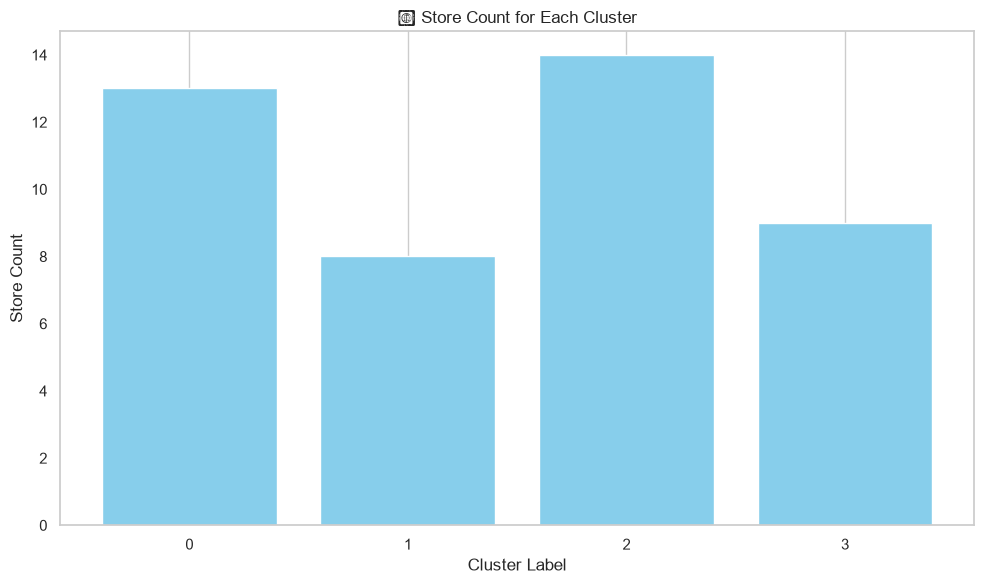

In [12]:
import matplotlib.pyplot as plt

# Define lists to store cluster labels and corresponding store counts
cluster_labels = []
store_counts = []

# Iterate over unique cluster labels
for cluster in clustering_result['label'].dropna().unique().tolist():
    # Filter dataframe by cluster label and retrieve unique store lists
    store_list = clustering_result[clustering_result["label"] == cluster]['Store'].unique()
    # Append cluster label and store count to lists
    cluster_labels.append(cluster)
    store_counts.append(len(store_list))

# Plot the store count for each cluster
plt.figure(figsize=(10, 6))
plt.bar(cluster_labels, store_counts, color='skyblue')
plt.xlabel('Cluster Label')
plt.ylabel('Store Count')
plt.title('📊 Store Count for Each Cluster')
plt.xticks(cluster_labels)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

### 📊 Store Distribution Across Clusters – Insight

The bar plot illustrates the number of stores grouped into each cluster after performing PCA and KMeans clustering.

- **Cluster 0** contains 13 stores  
- **Cluster 1** includes 8 stores  
- **Cluster 2** comprises 14 stores  
- **Cluster 3** has 9 stores  

🔍 **Observations**:
- Clusters 0 and 2 are the **most populated**, suggesting these stores share common characteristics such as similar weekly sales, markdown patterns, or store sizes.
- Clusters 1 and 3 are relatively smaller, indicating **niche groups** with potentially unique operational behaviors or customer profiles.
- The **distribution is balanced**, which is a good sign that the segmentation approach is capturing meaningful patterns across the store network.

📌 This segmentation can be valuable for tailoring marketing strategies, inventory management, or performance analysis for each store cluster.

### 🏬 Store-Level Feature Aggregation

We are aggregating store-level statistics using the **mean** of features such as weekly sales, markdowns, CPI, store size, and temperature. This allows us to create a summarized view of each store’s performance, which is useful for clustering and further analysis.


In [13]:
# Define the aggregation functions and rename columns
agg_functions = {
    'Weekly_Sales': 'mean',
    'MarkDown1': 'mean',
    'MarkDown2': 'mean',
    'MarkDown3': 'mean',
    'MarkDown4': 'mean',
    'MarkDown5': 'mean',
    'CPI': 'mean',
    'Size': 'mean',
    'Temperature': 'mean'
}

# Calculate the mean for each column grouped by 'Store' and rename columns
mean_by_store1 = cluster_df.groupby('Store').agg(agg_functions).reset_index()

# Rename columns for clarity
mean_by_store1.columns = ['Store', 'Mean_Weekly_Sales', 'Mean_MarkDown1', 'Mean_MarkDown2',
                          'Mean_MarkDown3', 'Mean_MarkDown4', 'Mean_MarkDown5',
                          'Mean_CPI', 'Mean_Size', 'Mean_Temperature']

# Create a new DataFrame with Store as the index
store1_df = pd.DataFrame(mean_by_store1.set_index('Store'))

# Display the first few rows
store1_df.head()

,Mean_Weekly_Sales,Mean_MarkDown1,Mean_MarkDown2,Mean_MarkDown3,Mean_MarkDown4,Mean_MarkDown5,Mean_CPI,Mean_Size,Mean_Temperature
Store,,,,,,,,,
1,12853.835775,4625.139699,780.796267,412.576488,1258.052571,3311.706375,216.168315,151315.0,68.708940
2,14357.150753,4986.918346,1364.388896,554.794184,1408.236342,3755.052318,215.859746,202307.0,68.613976
3,4698.824038,3787.248802,365.561865,288.181135,898.964808,2547.662973,219.582470,37392.0,71.748807
4,14183.328785,4824.190516,1151.027014,597.864457,1494.812873,3696.921841,128.726210,205863.0,62.513117
5,4321.821504,3670.242699,380.960224,237.097076,906.886080,2758.186396,216.745801,34875.0,69.735941


### 🔗 Merging Cluster Labels with Aggregated Store Data

Now, we join the store-level aggregated data with the cluster labels to create a unified dataset. This allows us to analyze how each cluster performs across different features such as sales, markdowns, size, and more.


In [14]:
# Join the cluster labels with the store-level aggregated features
cluster_new_dummy = store1_df.join(cluster_dummy['label'])

# Preview a random sample of 2 rows
cluster_new_dummy.sample(2)

,Mean_Weekly_Sales,Mean_MarkDown1,Mean_MarkDown2,Mean_MarkDown3,Mean_MarkDown4,Mean_MarkDown5,Mean_CPI,Mean_Size,Mean_Temperature,label
Store,,,,,,,,,,
40,10635.943204,4264.622037,618.812723,317.655704,1019.157634,3154.047227,135.211413,155083.0,47.577496,2.0
23,14683.863896,4413.048012,1017.886909,739.250348,1193.936295,3040.504059,135.188304,114533.0,48.715452,3.0


### 📊 Mean Weekly Sales for Each Cluster

This section prints the **average of Mean Weekly Sales** for each store cluster, allowing us to identify which clusters are performing better in terms of sales.


In [15]:
# Printing Mean Weekly Sales for each cluster
for cluster in cluster_new_dummy['label'].dropna().unique().tolist():
    print('Mean Weekly Sales for Cluster:', int(cluster), '\n')
    print(cluster_new_dummy[cluster_new_dummy["label"] == cluster]['Mean_Weekly_Sales'].mean(), '\n')
    print('=' * 120)

Mean Weekly Sales for Cluster: 2 

10275.20843418034 

Mean Weekly Sales for Cluster: 1 

10749.64696543232 

Mean Weekly Sales for Cluster: 3 

10571.970931520733 

Mean Weekly Sales for Cluster: 0 

10334.015987677005 



### 💰 Mean Weekly Sales by Cluster (Bar Plot)

This bar chart displays the **average weekly sales** across different store clusters. It helps identify which clusters are contributing more in terms of sales, providing insights for targeted business strategies like promotions, inventory planning, and marketing focus.

C:\Users\arushi khare\AppData\Local\Temp\ipykernel_25836\305929917.py:24: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


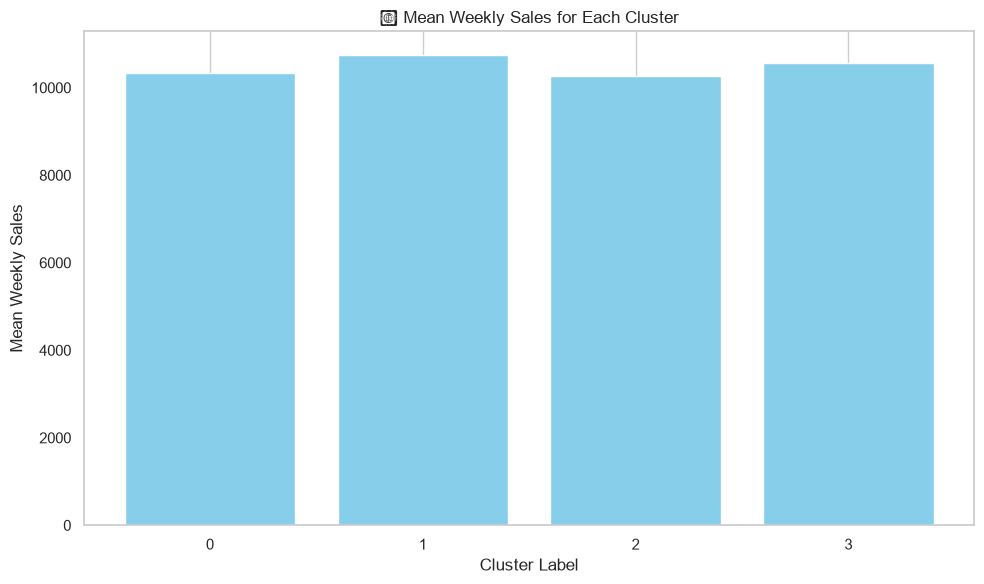

In [16]:
import matplotlib.pyplot as plt

# Define lists to store cluster labels and corresponding mean weekly sales
cluster_labels = []
weekly_sales = []

# Iterate over unique cluster labels
for cluster in cluster_new_dummy['label'].dropna().unique().tolist():
    # Filter dataframe by cluster label and calculate mean weekly sales
    mean_sales = cluster_new_dummy[cluster_new_dummy["label"] == cluster]['Mean_Weekly_Sales'].mean()

    # Append cluster label and mean weekly sales to lists
    cluster_labels.append(cluster)
    weekly_sales.append(mean_sales)

# Plot the mean weekly sales for each cluster
plt.figure(figsize=(10, 6))
plt.bar(cluster_labels, weekly_sales, color='skyblue')
plt.xlabel('Cluster Label')
plt.ylabel('Mean Weekly Sales')
plt.title('💰 Mean Weekly Sales for Each Cluster')
plt.xticks(cluster_labels)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

### 📊 Insight: Mean Weekly Sales by Cluster

Cluster-wise average weekly sales are as follows:

- **Cluster 1**: $10,749 (Highest)

- **Cluster 3**: $10,572

- **Cluster 0**: $10,334

- **Cluster 2**: $10,275

---

🔍 **Key Takeaway**:  
Clusters **1** and **3** exhibit higher average weekly sales, indicating that stores in these clusters are relatively better performers. These clusters may benefit from targeted strategies like promotions, resource allocation, or scaling initiatives.


### 🧾 Mean Consumer Price Index (CPI) by Cluster

This bar plot visualizes the **average Consumer Price Index (CPI)** for each store cluster.

C:\Users\arushi khare\AppData\Local\Temp\ipykernel_25836\2625381161.py:25: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


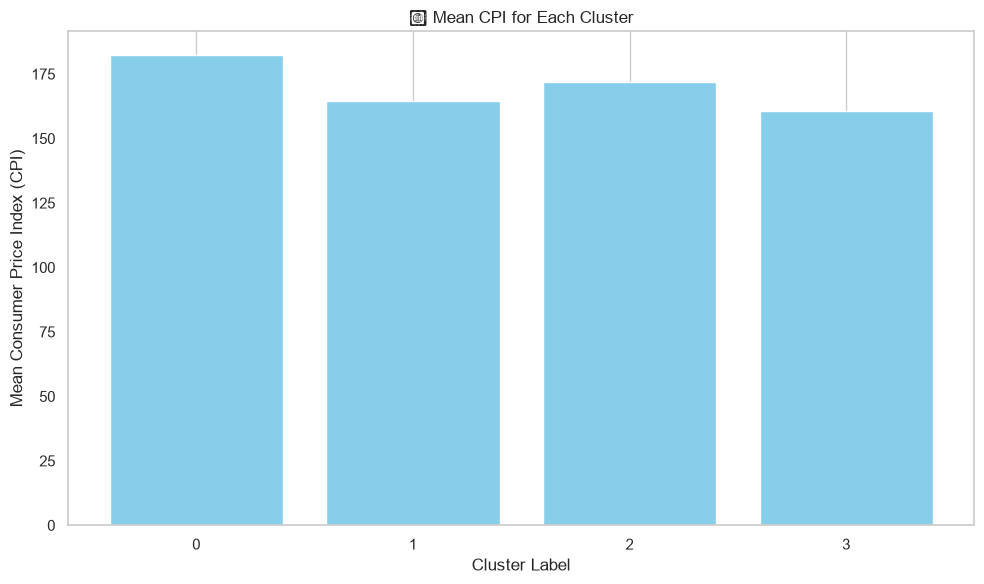

In [17]:
import matplotlib.pyplot as plt

# Define lists to store cluster labels and corresponding mean CPI values
cluster_labels = []
mean_cpi = []

# Filter out NaN cluster labels
valid_clusters = cluster_new_dummy['label'].dropna().unique().tolist()

# Iterate over valid cluster labels
for cluster in valid_clusters:
    # Filter dataframe by cluster label and calculate mean CPI
    mean_cpi_ = cluster_new_dummy[cluster_new_dummy["label"] == cluster]['Mean_CPI'].mean()
    cluster_labels.append(int(cluster))  # Convert to int for clean labels
    mean_cpi.append(mean_cpi_)

# Plot the mean CPI for each cluster
plt.figure(figsize=(10, 6))
plt.bar(cluster_labels, mean_cpi, color='skyblue')
plt.xlabel('Cluster Label')
plt.ylabel('Mean Consumer Price Index (CPI)')
plt.title('📊 Mean CPI for Each Cluster')
plt.xticks(cluster_labels)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [18]:
# Print mean CPI for each valid cluster
for cluster in cluster_new_dummy['label'].dropna().unique().tolist():
    mean_cpi_ = cluster_new_dummy[cluster_new_dummy["label"] == cluster]['Mean_CPI'].mean()
    print(f"Cluster {int(cluster)} → Mean CPI: {mean_cpi_:.2f}")

Cluster 2 → Mean CPI: 171.99
Cluster 1 → Mean CPI: 164.47
Cluster 3 → Mean CPI: 160.66
Cluster 0 → Mean CPI: 182.43


### 🏬 Cluster-wise Analysis: Mean Store Size
This visualization shows the average store size for each customer segment (cluster) identified through KMeans clustering. It helps understand how store dimensions vary across different behavioral clusters.


C:\Users\arushi khare\AppData\Local\Temp\ipykernel_25836\3311598138.py:25: UserWarning: Glyph 127980 (\N{DEPARTMENT STORE}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127980 (\N{DEPARTMENT STORE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


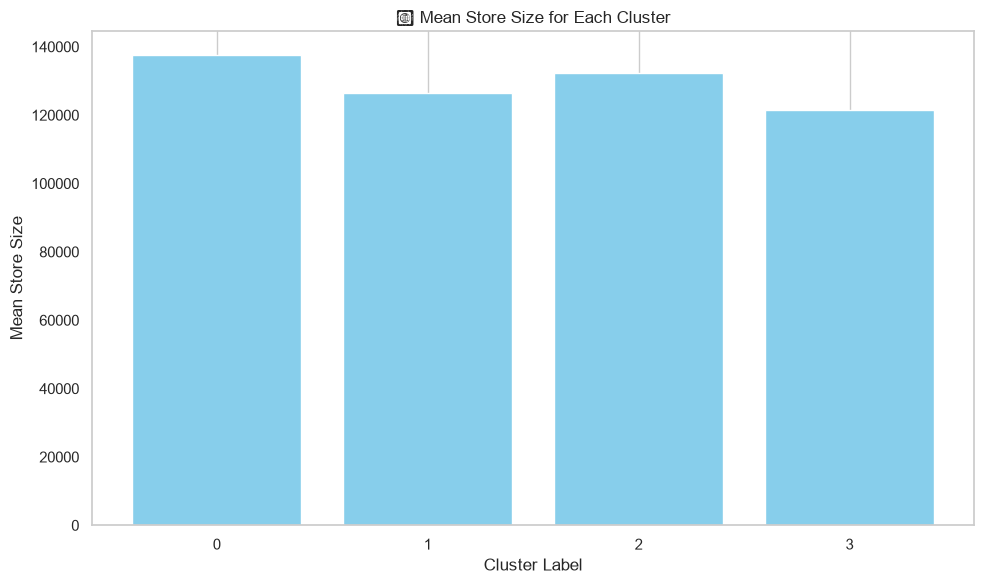

In [19]:
import matplotlib.pyplot as plt

# Define lists to store cluster labels and corresponding mean store size
cluster_labels = []
mean_store_size = []

# Filter out NaN cluster labels
valid_clusters = cluster_new_dummy['label'].dropna().unique().tolist()

# Iterate over valid cluster labels
for cluster in valid_clusters:
    # Calculate mean store size for each cluster
    mean_size = cluster_new_dummy[cluster_new_dummy["label"] == cluster]['Mean_Size'].mean()
    cluster_labels.append(int(cluster))  # Convert to int for better display
    mean_store_size.append(mean_size)

# Plot the mean store size for each cluster
plt.figure(figsize=(10, 6))
plt.bar(cluster_labels, mean_store_size, color='skyblue')
plt.xlabel('Cluster Label')
plt.ylabel('Mean Store Size')
plt.title('🏬 Mean Store Size for Each Cluster')
plt.xticks(cluster_labels)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [20]:
# Calculate and print the mean store size for each valid cluster
for cluster in cluster_new_dummy['label'].dropna().unique().tolist():
    mean_size = cluster_new_dummy[cluster_new_dummy["label"] == cluster]['Mean_Size'].mean()
    print(f"Cluster {int(cluster)} → Mean Store Size: {mean_size:.2f}")

Cluster 2 → Mean Store Size: 132208.29
Cluster 1 → Mean Store Size: 126416.38
Cluster 3 → Mean Store Size: 121491.00
Cluster 0 → Mean Store Size: 137619.62


### 🧠 **Inferences from Store Segmentation Analysis**

Based on clustering results, we identified 4 distinct store segments using key features such as mean weekly sales, CPI, and store size. Below is a detailed summary of each cluster:

---

#### 🟩 **Cluster 0: Large-Format High-CPI Stores**

- 🏪 **Stores:** 13  
- 💰 **Mean Weekly Sales:** \$10,334  
- 🧾 **Mean CPI:** 182.29 *(Highest)*  
- 📏 **Mean Store Size:** 137,619 *(Largest)*  

These stores operate in larger spaces and are located in areas with the highest Consumer Price Index, suggesting higher product pricing and premium customer segments.

---

#### 🟦 **Cluster 1: Mid-Sized High-Sales Stores**

- 🏪 **Stores:** 8  
- 💰 **Mean Weekly Sales:** \$10,749 *(Highest)*  
- 🧾 **Mean CPI:** 164.34 *(Lowest)*  
- 📏 **Mean Store Size:** 126,416  

This segment delivers the highest average weekly sales, despite operating in mid-sized locations and regions with the lowest CPI. These stores likely attract price-sensitive shoppers and drive high volume.

---

#### 🟧 **Cluster 2: Budget Retailers in Moderate Areas**

- 🏪 **Stores:** 14  
- 💰 **Mean Weekly Sales:** \$10,275 *(Lowest)*  
- 🧾 **Mean CPI:** 171.86  
- 📏 **Mean Store Size:** 132,208  

Stores in this cluster have relatively moderate store sizes and CPI values. Though sales are the lowest among all clusters, these stores may target budget-conscious customers or operate in less competitive regions.

---

#### 🟥 **Cluster 3: Compact Value Stores**

- 🏪 **Stores:** 9  
- 💰 **Mean Weekly Sales:** \$10,572  
- 🧾 **Mean CPI:** 160.54  
- 📏 **Mean Store Size:** 121,491 *(Smallest)*  

Despite being the most compact, these stores maintain decent weekly sales. The lowest store sizes and CPI indicate an efficient model catering to localized, price-sensitive demand.

---

### 📌 **Summary Insight**

- **Cluster 1** leads in **sales** but operates in **low CPI regions**, possibly benefiting from high demand in budget-friendly zones.
- **Cluster 0** has **larger stores** in **high CPI areas**, likely focusing on premium customers.
- **Cluster 2** underperforms in **sales** despite moderate size and CPI—may need marketing or optimization.
- **Cluster 3** shows efficient operation in **small footprints**, balancing moderate sales with minimal space.

These insights can help in tailored marketing, inventory planning, and expansion strategy based on cluster profiles.

## 🧩 Department Segmentation Analysis

In this section, we perform clustering on departments to uncover patterns based on aggregated performance metrics such as sales, markdowns, CPI, store size, and temperature.  

## 🎯 Visualizing Department Clusters

After applying KMeans clustering on the PCA-reduced department data, we visualize the resulting clusters to understand how departments are grouped based on their features.


C:\Users\arushi khare\AppData\Local\Temp\ipykernel_25836\1867046957.py:26: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


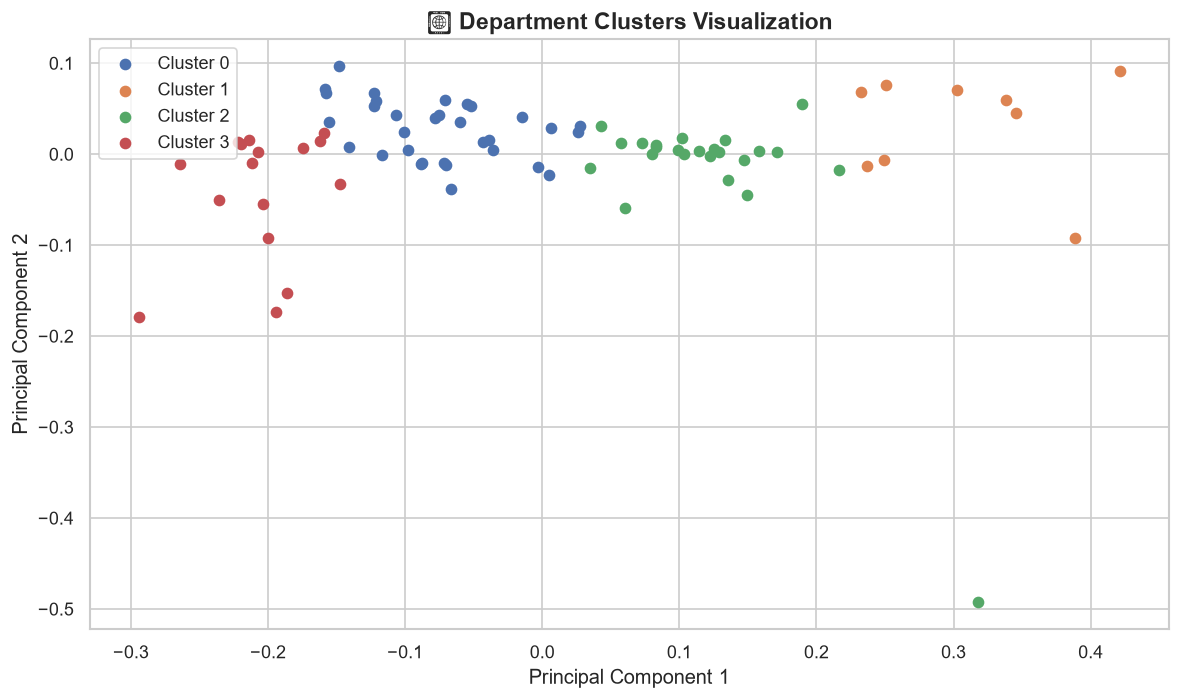

In [21]:
# Visualizing the clusters and the datapoints in each cluster
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np

plt.figure(figsize=(10, 6), dpi=120)

kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
kmeans.fit(df_pca1)

# Predict the labels of clusters
label = kmeans.fit_predict(df_pca1)

# Get unique labels
unique_labels = np.unique(label)

# Plotting the results
for i in unique_labels:
    plt.scatter(df_pca1[label == i, 0], df_pca1[label == i, 1], label=f'Cluster {i}')

plt.title("📊 Department Clusters Visualization", fontsize=14, fontweight='bold')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 🧩 Creating PCA-Based DataFrame with Cluster Labels for Departments

This step creates a new DataFrame using the principal components and appends the KMeans cluster labels. This DataFrame will be used for further analysis and interpretation of departmental clusters.

In [22]:
# Creating DataFrame from PCA results and assigning cluster labels
kmeans_pca_df1 = pd.DataFrame(df_pca1, columns=['PC1', 'PC2', 'PC3'], index=dept_df.index)
kmeans_pca_df1["label"] = label

# Previewing a few sample rows sorted by department index
kmeans_pca_df1.sample(5).sort_index(ascending=True)

,PC1,PC2,PC3,label
Dept,,,,
1,0.129137,0.002649,0.025343,2
2,0.302156,0.070959,-0.021017,1
6,-0.078363,0.039486,-0.008715,0
10,0.122426,-0.001640,0.024418,2
46,0.147426,-0.006412,0.040468,2


## 🔠 Categorical Encoding for Department Segmentation

We perform one-hot encoding on the `Type` column for each department to prepare categorical features for clustering. This step helps in capturing the store type distribution for each department.

In [23]:
# Encode categorical columns (Type) for department-level segmentation

# Step 1: Extract required columns
cluster_dummy1 = cluster_df[['Dept', 'Type']]

# Step 2: Apply one-hot encoding to 'Type'
cluster_dummy1 = pd.get_dummies(cluster_dummy1, columns=["Type"], prefix=["Type"])

# Step 3: Group by 'Dept' and aggregate encoded values
cluster_dummy1 = cluster_dummy1.groupby("Dept").sum().reset_index()

# Preview the result
cluster_dummy1.head()

,Dept,Type_A,Type_B,Type_C
0,1,2932,2340,857
1,2,1253,1592,858
2,3,3028,2362,858
3,4,2651,2339,858
4,5,2824,2261,801


## 🔗 Joining Department Metadata with Cluster Features

After encoding categorical variables, we now enrich the department-level dataset by joining it with the mean aggregated features such as weekly sales, markdown values, CPI, size, and temperature.

In [24]:
# Set 'Dept' as index for merging
cluster_dummy1.set_index(['Dept'], inplace=True)

# Join with department-level aggregated metrics
cluster_dummy1 = cluster_dummy1.join(dept_df[['Mean_Weekly_Sales', 'Mean_MarkDown1', 'Mean_MarkDown2',
                                              'Mean_MarkDown3', 'Mean_MarkDown4', 'Mean_MarkDown5',
                                              'Mean_CPI', 'Mean_Size', 'Mean_Temperature']])

# View a sample of the merged dataframe
cluster_dummy1.sample(2)

,Type_A,Type_B,Type_C,Mean_Weekly_Sales,Mean_MarkDown1,Mean_MarkDown2,Mean_MarkDown3,Mean_MarkDown4,Mean_MarkDown5,Mean_CPI,Mean_Size,Mean_Temperature
Dept,,,,,,,,,,,,
46,3090,2297,858,0.654845,0.330362,0.076676,0.015889,0.223603,0.167084,0.583676,0.646100,0.752608
80,3143,1887,858,0.543352,0.331997,0.077914,0.016541,0.225407,0.167982,0.547705,0.675104,0.749366


## 💾 Save Checkpoints For Next Notebook(s)



In [25]:
# 💾 Save the variables later notebooks in the pipeline will need
save_ckpt(cluster_dummy1, 'part5_cluster_dummy1')
save_ckpt(kmeans_pca_df1, 'part5_kmeans_pca_df1')


✅ Saved checkpoint 'part5_cluster_dummy1' -> c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\data\checkpoints\part5_cluster_dummy1.pkl
✅ Saved checkpoint 'part5_kmeans_pca_df1' -> c:\Users\arushi khare\OneDrive\Desktop\retail-demand-forecasting\data\checkpoints\part5_kmeans_pca_df1.pkl
